# World's largest islands

This dataset `largest-islands.csv` contains information about the 100 largest islands in the world. The unit for the `area` column is km2.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'largest-islands.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('largest-islands.csv')
df.head()

,region,island,area,countries,climate,rank
0,Africa,Madagascar,591896,Madagascar,tropics,4
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France",temperate,91
2,Asia,Sumba,11153,Indonesia,tropics,65
3,Asia,Hainan,34300,China,tropics,37
4,Asia,Taiwan,36198,Taiwan,tropics,36


### Project Ideas

- What are the 10 largest islands in the tropics?

- What are the largest islands in each `region`?

- Create a line graph with `area` on the y-axis and `rank` on the x-axis. The data should be ordered by `rank`, from largest to smallest.

- What islands are composed of multiple countries?
	- Hint: try `countries.str.contains(",")`

### Solutions

- What are the 10 largest islands in the tropics?

To answer that question, I am going to sort the dataframe using **sort_value()** and **head()** functions specifying 10 inside, in that way I'll get the 10 largest islands.

In [12]:
df.query('climate=="tropics"').sort_values(by='area', ascending= False).head(10)

,region,island,area,countries,climate,rank
86,Oceania,New Guinea,821400,"Papua New Guinea, Indonesia",tropics,2
23,Asia,Borneo,755000,"Indonesia, Malaysia, Brunei",tropics,3
0,Africa,Madagascar,591896,Madagascar,tropics,4
28,Asia,Sumatra,480793,Indonesia,tropics,6
22,Asia,Sulawesi,188522,Indonesia,tropics,11
21,Asia,Java,129438,Indonesia,tropics,13
80,North America,Cuba,109884,Cuba,tropics,16
26,Asia,Luzon,104688,Philippines,tropics,17
14,Asia,Mindanao,94630,Philippines,tropics,19
73,North America,Hispaniola,76192,"Dominican Republic, Haiti",tropics,23


The previous dataframe shows the ten largest islands

-  What are the largest islands in each `region`?

To get this information I'll use max() function. From the below solutions Greenland is the largest island which area is $ \text {2166086 km} ^2$ in Europe. And the result shows the largest island in the other regions. 

Note: Column area is in $\text {km}^2$

In [ ]:

df_region = df.groupby('region')['area'].max().reset_index()

df.merge(df_region, on=['region','area'], how='inner')

# advanced way
#df.loc[df['area'].idxmax()] # -> return a serie



,region,island,area,countries,climate,rank
0,Africa,Madagascar,591896,Madagascar,tropics,4
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France",temperate,91
2,Asia,Borneo,755000,"Indonesia, Malaysia, Brunei",tropics,3
3,Eurasia,Sakhalin,76400,Russia,temperate,22
4,Europe,Greenland,2166086,Denmark,polar,1
5,North America,Baffin Island,507451,Canada,polar,5
6,Oceania,New Guinea,821400,"Papua New Guinea, Indonesia",tropics,2
7,South America,Isla Grande de Tierra del Fuego,47992,"Chile, Argentina",temperate,28


- Create a line graph with `area` on the y-axis and `rank` on the x-axis. The data should be ordered by `rank`, from largest to smallest.

To create a line graph use **plot()** ,
sort values using **sort_values()** function DESC, 
I include **gca()** which stands for "get current axes" (axes is the area where the data is drawn, that include x-axis and y-axis) then specify the axis that I want to invert using **invert_xaxis()**

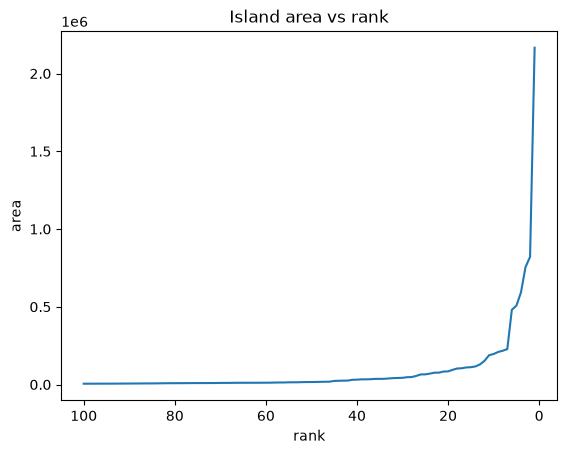

In [37]:
df_sorted = df.sort_values('rank', ascending=False)

plt.plot(df_sorted['rank'],df_sorted['area'])
plt.xlabel('rank')
plt.ylabel('area')
plt.title('Island area vs rank')
plt.gca().invert_xaxis() # flips the x-axis direction

- What islands are composed of multiple countries?
	- Hint: try `countries.str.contains(",")`

<column/series>.str.contains("<something>"): Test if a word or regex is contained in a string.

<sub>source of documentation: https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html</sub>

In [38]:
df.query('countries.str.contains(",")')

,region,island,area,countries,climate,rank
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France",temperate,91
23,Asia,Borneo,755000,"Indonesia, Malaysia, Brunei",tropics,3
45,Europe,Ireland,84421,"Ireland, United Kingdom",temperate,20
50,Europe,Cyprus,9251,"Cyprus, United Kingdom",temperate,76
73,North America,Hispaniola,76192,"Dominican Republic, Haiti",tropics,23
86,Oceania,New Guinea,821400,"Papua New Guinea, Indonesia",tropics,2
98,South America,Isla Grande de Tierra del Fuego,47992,"Chile, Argentina",temperate,28


From previous query we can conclude that the islands composed by multiple countries are:
- Kerguelen
- Borneo
- Ireland
- Cyprus
- Hispaniola
- New Guinea
- Isla Grande de Tierra del Fuego